## Ejercicio 1
Implemente una función para el cálculo y graficación del espectrograma a partir de ciclos for y la transformada rápida de Fourier fft

In [301]:
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [ ]:
def get_window(name):
    default = np.hamming
    windows = {
        "square": np.ones,
        "hamming": np.hamming,
        "hanning": np.hanning,
        "blackman": np.blackman,
        "gaussian": lambda N: np.exp(-0.5 * ((np.arange(N) - (N-1)/2) / (0.4 * (N-1)/2))**2)
    }
    window = windows[name] if name in windows.keys() else default
    return window

In [303]:
def generate_spectrogram(x,fm,window_size=256, n_overlap=None, window_type="hamming"):
    if n_overlap == None:
        n_overlap = window_size // 2
    step = window_size - n_overlap
    delta_t = 1/fm
    delta_f = fm/window_size
    
    #el inicio de la última ventana es: longitud de la señal - ancho de la ventana.
    # Sumo 1 porque arange hace [inicio,fin)
    last_window_start = len(x)-window_size + 1
    starts = np.arange(0,last_window_start, step)
    
    # Creo la ventana (fuera del bucle porque siempre es la misma
    # para "centrarla" simplemente voy a ir recortando partes de la señal)
    window_f = get_window(window_type)
    window = window_f(window_size)
    
    #acá guardamos el cuadrado de las frecuencias (espectrograma).
    # El //2 es porque la rfftdevuelve solo la mitad
    # de los coeficientes(no devuelve los conjugados)
    S = np.empty((window_size // 2 + 1, len(starts)))
    times = np. empty(len(starts))
    
    for k, start in enumerate(starts):
        # si start+window_size sobrepasa el largo de x, numpy nos devuelve hasta donde da x,
        # entonces x_k puede ser de largo menor a window_size
        x_k = x[start:start+window_size]    
        #completo con ceros si x_k no llega al largo de la ventana
        frame = np.zeros(window_size)
        frame[:len(x_k)] = x_k
        
        freqs_window = np.fft.rfft(frame * window)
        times[k] = (start + window_size / 2) * delta_t
        S[:,k] = np.abs(freqs_window)**2
        
    freqs = np.arange(0,fm/2 + 1, delta_f)
    S_db = 10 * np.log10(np.maximum(S, 1e-10))
    
    return times, freqs, S_db
        
    
def plot_spectogram(times, freqs, S_db, cmap='magma'):
    fig, ax = plt.subplots(figsize=(10, 4))
    pcm = ax.pcolormesh(times, freqs, S_db, cmap=cmap, shading='auto')
    fig.colorbar(pcm, ax=ax, label='Potencia (dB)')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_title('Espectrograma')
    plt.tight_layout()
    plt.show()

Probamos

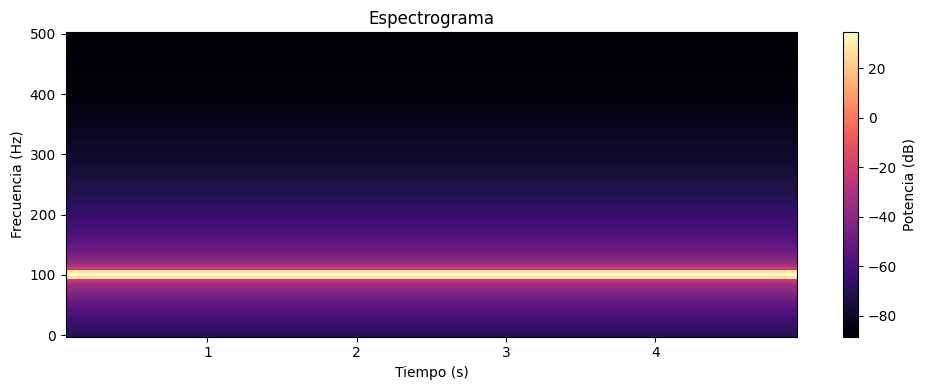

In [304]:
fm = 1000
fs = 100
t = np.arange(start=0,stop=5,step=1/fm)
x = np.sin(2*np.pi * fs * t)

times, freqs, S_db = generate_spectrogram(x,fm,window_size=200)
plot_spectogram(times,freqs,S_db)

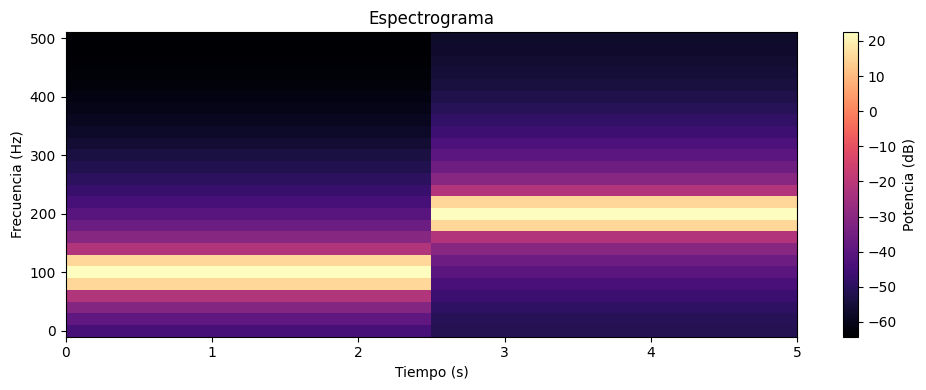

In [305]:
fm = 1000
t = np.arange(start=0,stop=5,step=1/fm)

x1 = np.sin(2*np.pi * 100 * t)
x2 = np.sin(2*np.pi * 200 * t)
x3 = np.concatenate((x1[:len(x1)//2],x2[len(x2)//2:]))

times, freqs, S_db = generate_spectrogram(x3,fm,window_size=50, n_overlap=0)
plot_spectogram(times,freqs,S_db)

## Ejercicio 2

<Axes: >

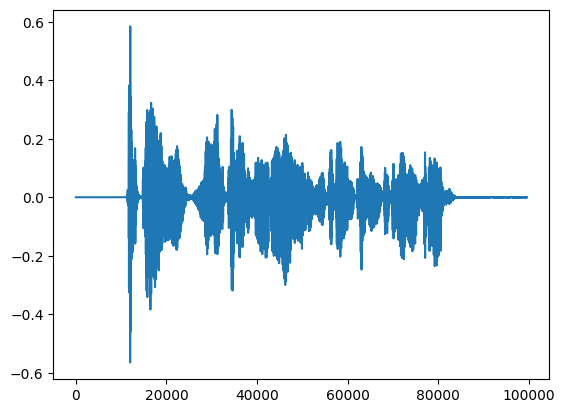

In [306]:
y, sr = librosa.load('data/ej2.wav')

sns.lineplot(y)

**Probamos distintos anchos de ventana**

Ancho ventana: 10


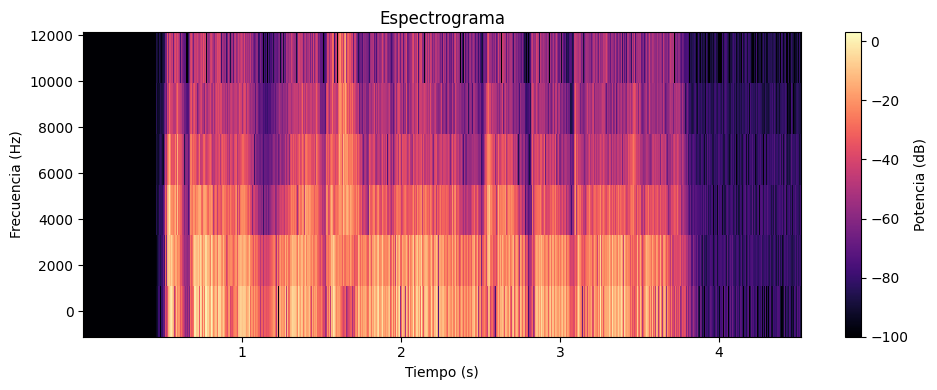

Ancho ventana: 50


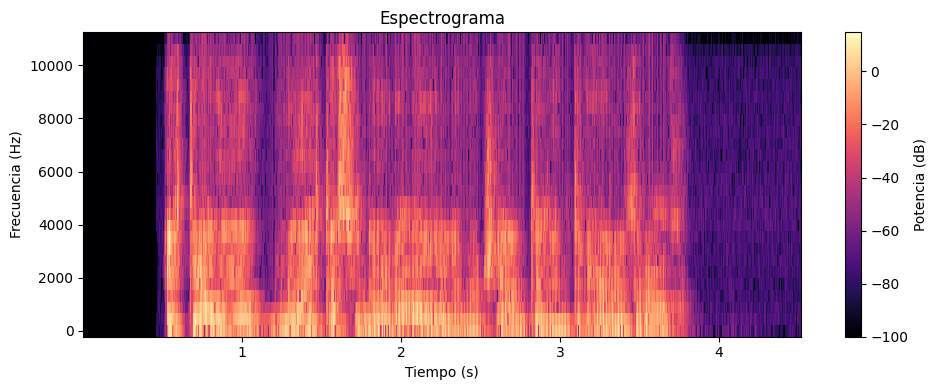

Ancho ventana: 100


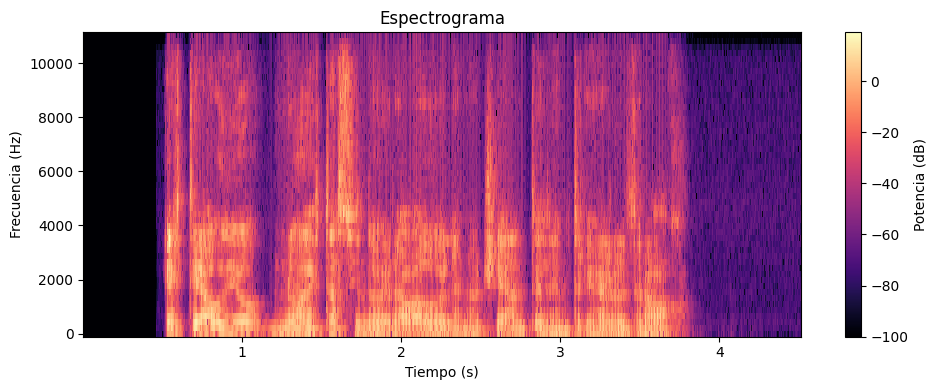

Ancho ventana: 200


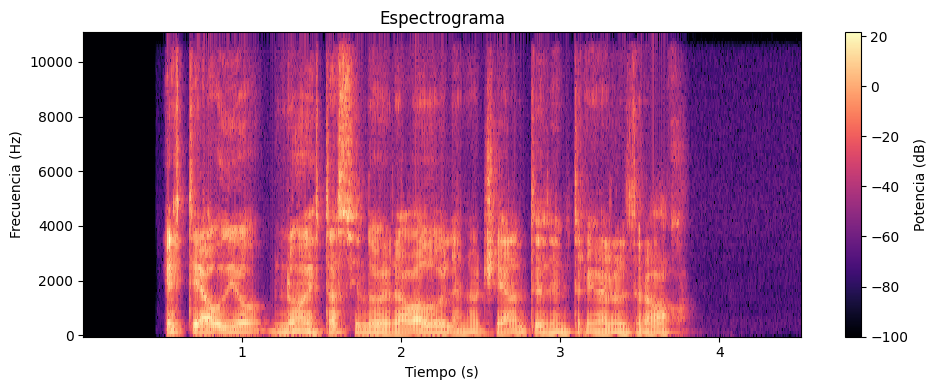

Ancho ventana: 500


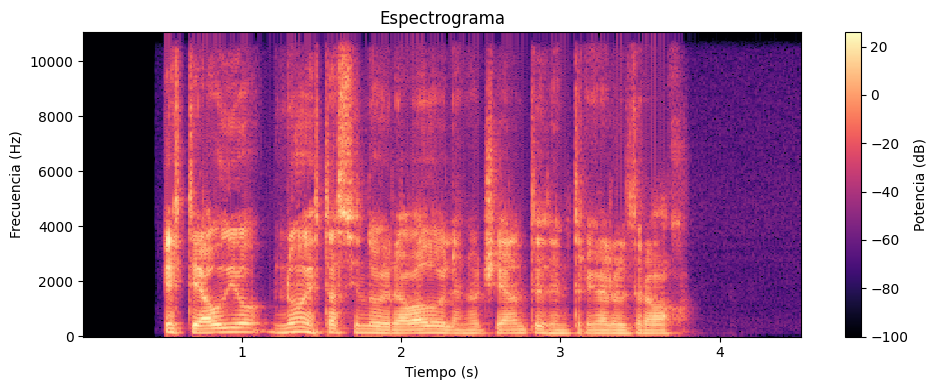

Ancho ventana: 3000


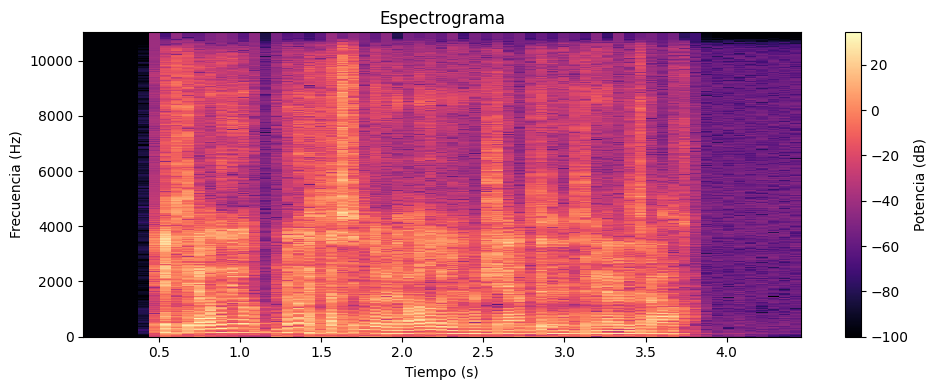

In [307]:
sizes = [10,50,100,200,500, 3000]

for window_size in sizes:
    print(f"Ancho ventana: {window_size}")
    times, freqs, S_db = generate_spectrogram(y,sr,window_size=window_size)
    plot_spectogram(times,freqs,S_db)

**Probamos distintos solapamientos**

Solapamiento (muestras): 0


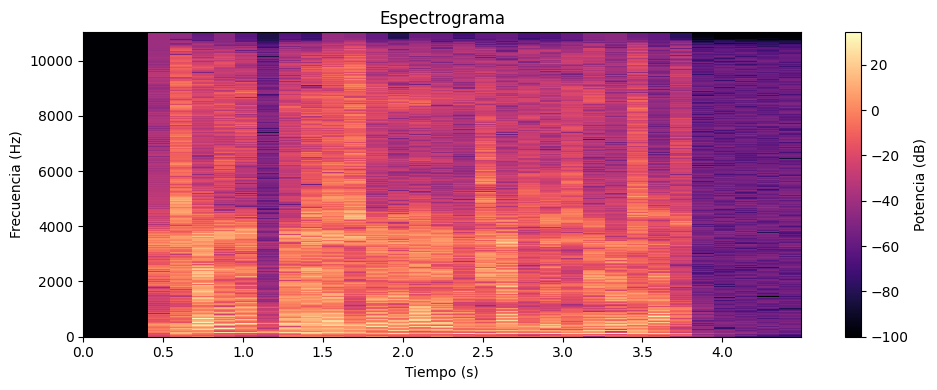

Solapamiento (muestras): 300


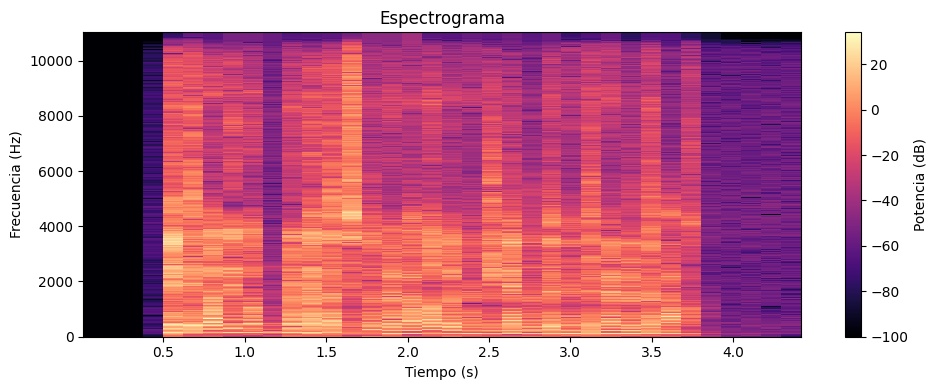

Solapamiento (muestras): 750


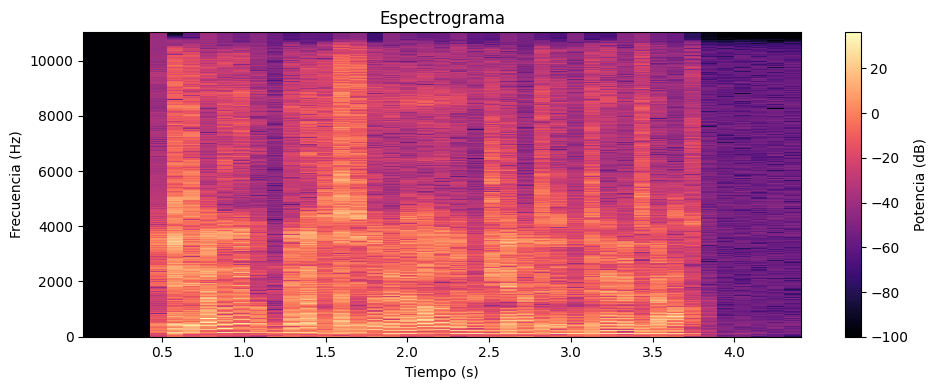

Solapamiento (muestras): 1500


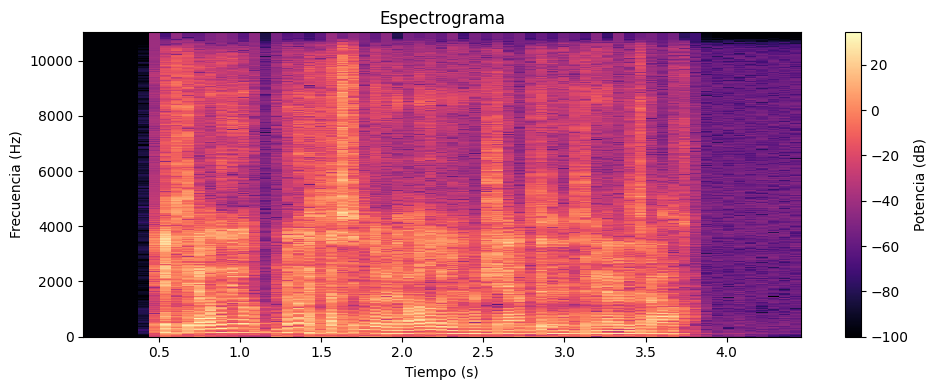

Solapamiento (muestras): 2250


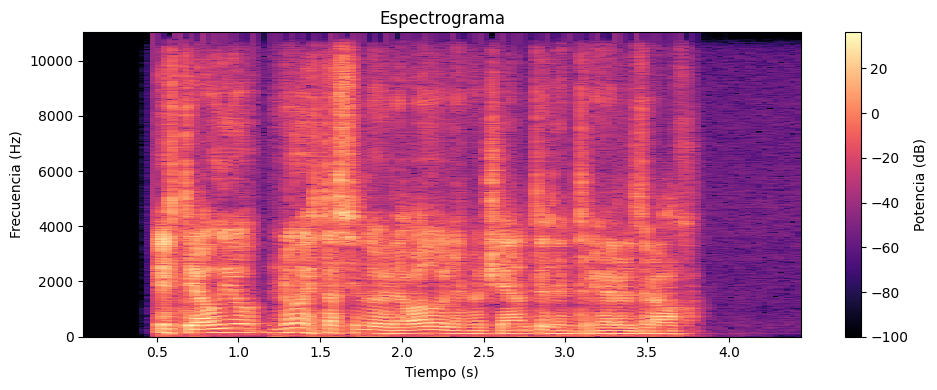

In [308]:
ws = 3000

# 0% 10% 25% 50% 75%
overlaps = [0, ws//10, ws//4, ws//2, 3*ws//4]

for overlap in overlaps:
    print(f"Solapamiento (muestras): {overlap}")
    times, freqs, S_db = generate_spectrogram(y,sr,n_overlap=overlap,window_size=ws)
    plot_spectogram(times,freqs,S_db)

In [309]:
display(Audio(y, rate=sr, normalize=False))

## Ejercicio 3 

Ver hojita con el cálculo de $\theta(t)$ (integrando)

In [310]:
fm = 1000

n = np.arange(start=0,stop=1,step=1/fm)
x_sin = np.sin(2 * np.pi * (100 + 50*n)*n)

<Axes: >

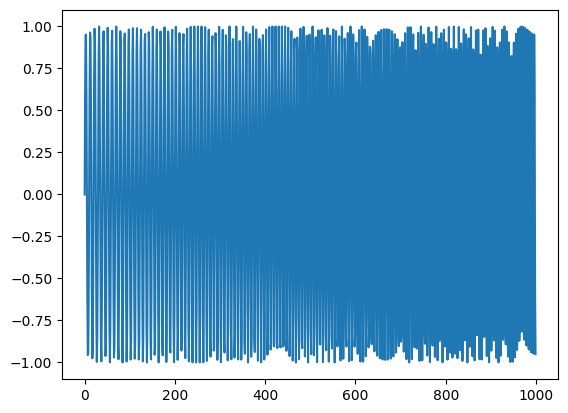

In [311]:
sns.lineplot(x_sin)

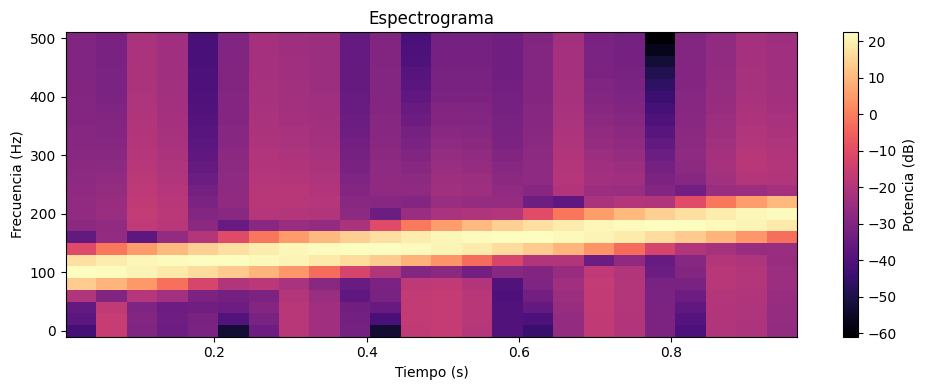

In [312]:
times, freqs, S_db = generate_spectrogram(x_sin,fm, window_size=50, n_overlap=10)

plot_spectogram(times, freqs, S_db)

## Ejercicio 4

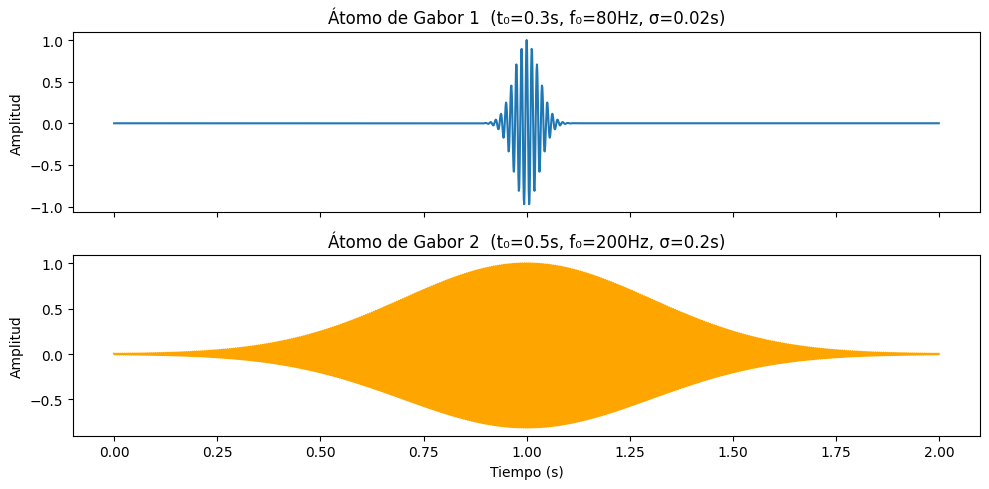

In [ ]:
def gabor_atom(t, t0, f0, sigma):
    gaussian = np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
    return gaussian * np.cos(2 * np.pi * f0 * (t - t0))

fm = 1000
t = np.arange(0, 2, 1/fm)

atom1 = gabor_atom(t, t0=1, f0=80, sigma=0.03)
atom2 = gabor_atom(t, t0=1, f0=200, sigma=0.3)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, atom1)
axes[0].set_title('Átomo de Gabor 1  (t₀=0.3s, f₀=80Hz, σ=0.03s)')
axes[0].set_ylabel('Amplitud')

axes[1].plot(t, atom2, color='orange')
axes[1].set_title('Átomo de Gabor 2  (t₀=0.5s, f₀=200Hz, σ=0.3s)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

Átomo 1  (σ=0.02s)


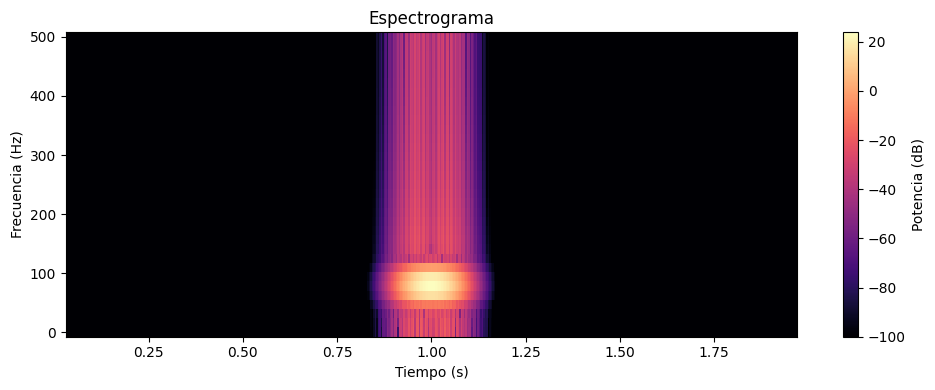

Átomo 2  (σ=0.2s)


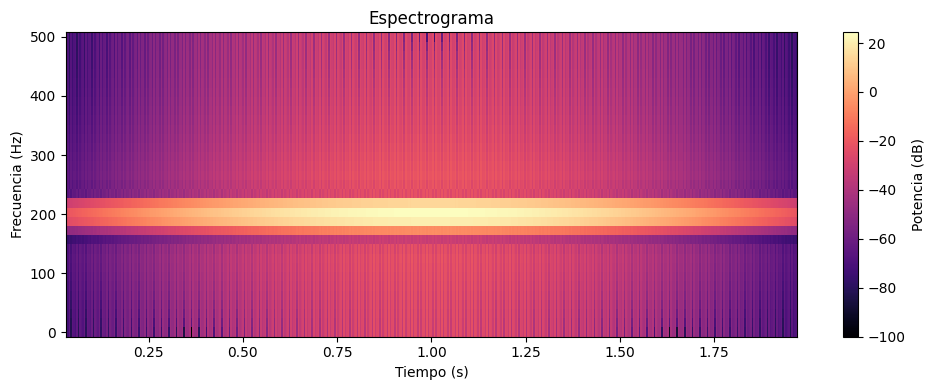

In [ ]:
for label, atom in [('Átomo 1  (σ=0.03s)', atom1), ('Átomo 2  (σ=0.3s)', atom2)]:
    print(label)
    times, freqs, S_db = generate_spectrogram(atom, fm, window_size=64, n_overlap=60)
    plot_spectogram(times, freqs, S_db)

## Ejercicio 5

Señal senoidal con frecuencia que crece linealmente de 0 a $8 \cdot f_m$. Como $8 \cdot f_m$ supera ampliamente la frecuencia de Nyquist ($f_m/2$), la señal va a aliasar: el espectrograma de Gabor mostrará la frecuencia instantánea "rebotando" dentro del rango $[0, f_m/2]$.

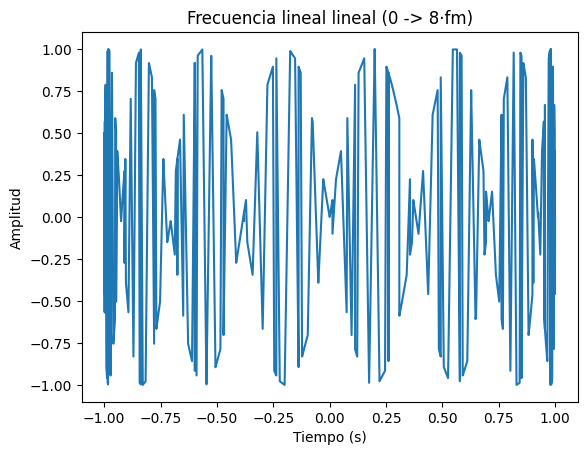

In [339]:
fm = 1000
t = np.arange(0, 1, 1/fm)

f1 = 2* fm/2
y = np.sin(np.pi * f1 * t**2)

sns.lineplot(x=y, y=x)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Frecuencia lineal lineal (0 -> 8·fm)')
plt.show()

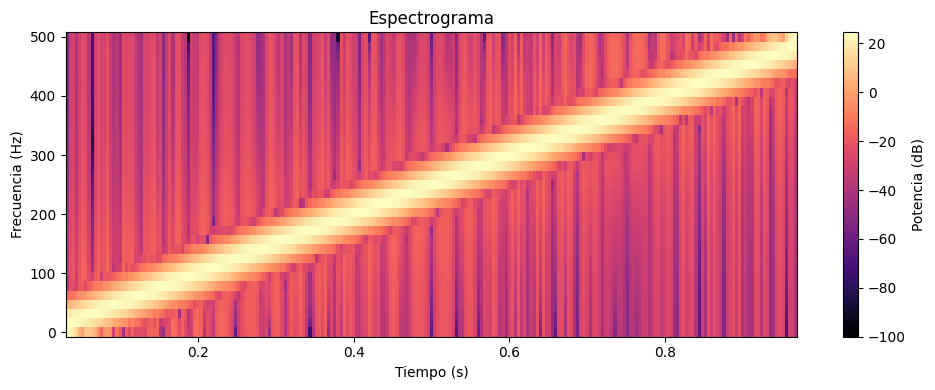

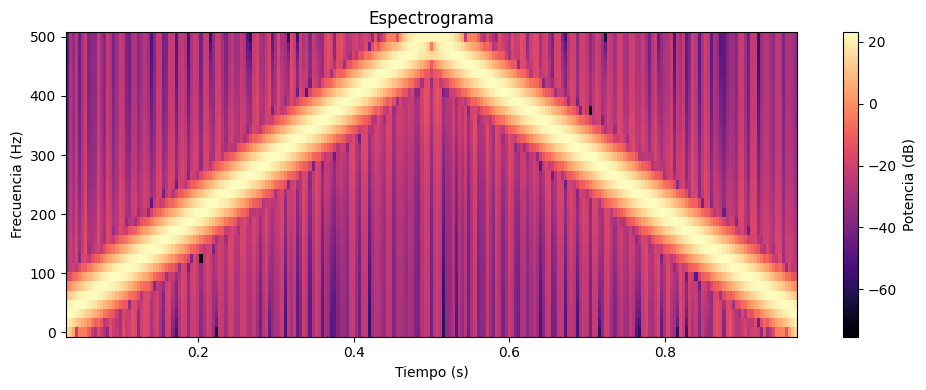

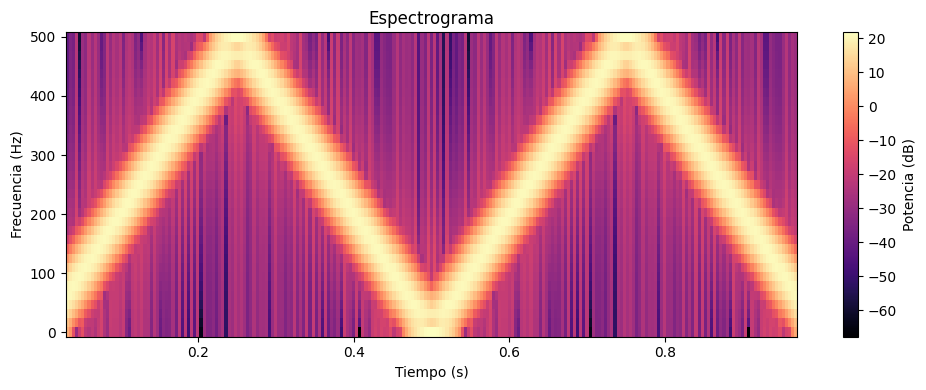

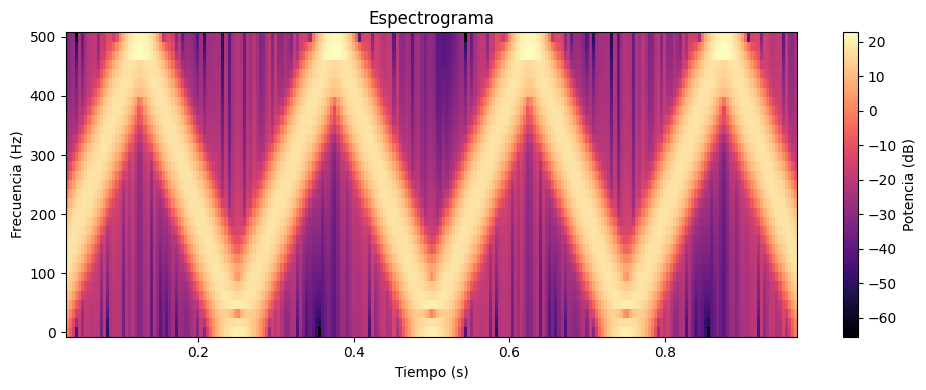

In [340]:
freqs_signal = [fm/2,2*fm/2,4*fm/2,8*fm/2]

for fs in freqs_signal:
    y = np.sin(np.pi * fs * t**2)
    times, freqs, S_db = generate_spectrogram(y, fm, window_size=64, n_overlap=60, window_type="gaussian")
    plot_spectogram(times, freqs, S_db)

## Ejercicio 6

<Axes: >

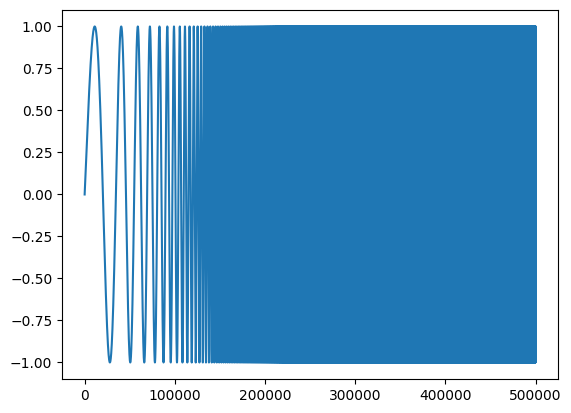

In [370]:
fm = 50000
beta=1
alfa=1
n = np.arange(start=0,stop=10,step=1/fm)
x_exp = np.sin(2 * np.pi * (beta/alfa)*np.exp(alfa * n))

sns.lineplot(x_exp)

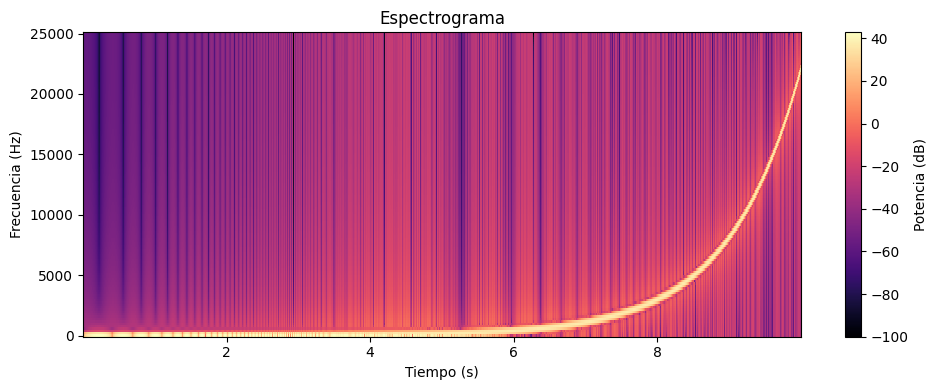

In [371]:
times, freqs, S_db = generate_spectrogram(x_exp,fm)
plot_spectogram(times, freqs, S_db)